--- BẢNG DỮ LIỆU VĨ MÔ VIỆT NAM (2020-2025) ---
 year  GDP_trillion_VND  GDP_billion_USD  GDP_growth_pct  GDP_per_capita_USD  population_million  agriculture_share_pct  industry_share_pct  services_share_pct  taxes_share_pct  agri_growth_pct  industry_growth_pct  services_growth_pct  inflation_CPI_pct  FDI_disbursed_billion_USD  exports_billion_USD  imports_billion_USD  digital_economy_share_GDP_pct  labor_productivity_million_VND
 2020            8044.4            346.6            2.91                3521               97.58                  12.66               36.74               41.63             8.97             2.68                 3.98                 2.34               3.23                      19.98                282.6                262.7                           12.0                           151.2
 2021            8487.5            366.1            2.58                3717               98.51                  12.36               37.86               40.95             8.83  

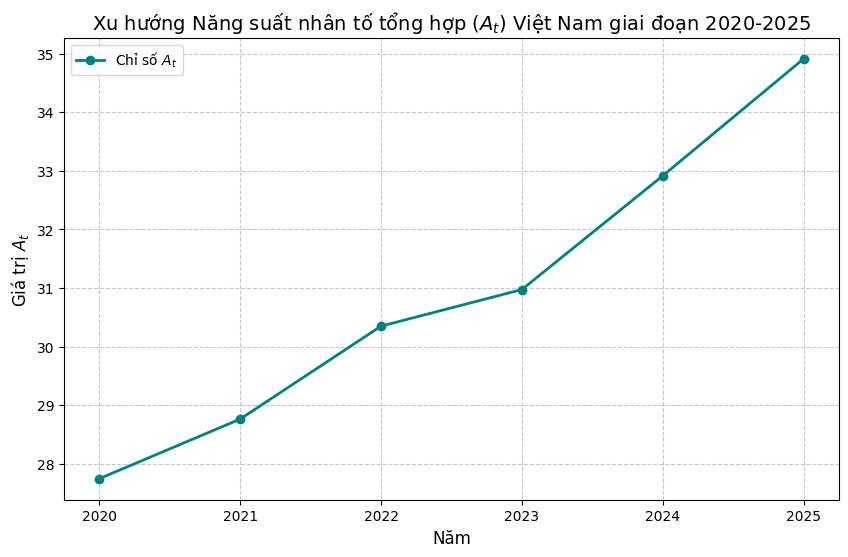

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc và hiển thị toàn bộ dữ liệu từ tệp vietnam_macro_2020_2025.csv
path = '../data/vietnam_macro_2020_2025.csv'

try:
    # Đọc dữ liệu
    df_macro = pd.read_csv(path)
    
    # Thiết lập pandas để hiển thị toàn bộ cột và hàng ngay ngắn
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("--- BẢNG DỮ LIỆU VĨ MÔ VIỆT NAM (2020-2025) ---")
    # Sử dụng to_string(index=False) để hiển thị toàn bộ 6 dòng (từ 2020 đến 2025)
    print(df_macro.to_string(index=False))
    
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file tại {path}. Hãy kiểm tra lại cấu trúc thư mục!")
    raise

# 2. Khởi tạo dữ liệu thực tế từ Bảng 1.3 (Dữ liệu Việt Nam 2020-2025) để tính A_t [1, 2]
# Chúng ta sử dụng trực tiếp các mảng số liệu từ tài liệu để đảm bảo tính chính xác theo yêu cầu
years = np.array([2020, 2021, 2022, 2023, 2024, 2025])
Y = np.array([8044.4, 8487.5, 9513.3, 10221.8, 11511.9, 12847.6]) # GDP (nghìn tỷ VND)
K = np.array([16500, 17800, 19600, 21300, 23500, 25900])         # Vốn tích lũy (nghìn tỷ)
L = np.array([53.6, 50.5, 51.7, 52.4, 52.9, 53.4])               # Lao động (triệu người)
D = np.array([12.0, 12.7, 14.3, 16.5, 18.3, 19.5])               # Kinh tế số/GDP (%)
AI = np.array([55.6, 60.2, 65.4, 67.0, 73.8, 80.1])              # DN công nghệ (nghìn)
H = np.array([24.1, 26.1, 26.2, 27.0, 28.4, 29.2])               # LĐ qua đào tạo (%)

# 3. Khai báo các hệ số co giãn đề xuất [2]
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07

# 4. Ước lượng năng suất nhân tố tổng hợp A_t bằng cách giải ngược từ hàm sản xuất [3, 4]
# Công thức: A_t = Y / (K^alpha * L^beta * D^gamma * AI^delta * H^theta)
A_t = Y / (K**alpha * L**beta * D**gamma * AI**delta * H**theta)

# Tạo dataframe kết quả tính toán A_t để hiển thị đẹp mắt
res_df = pd.DataFrame({
    'Năm': years, 
    'GDP (Y)': Y,
    'TFP (A_t)': A_t
})

print("\n--- KẾT QUẢ ƯỚC LƯỢNG NĂNG SUẤT NHÂN TỐ TỔNG HỢP (A_t) ---")
print(res_df.to_string(index=False))

# 5. Vẽ đồ thị xu hướng A_t theo năm
plt.figure(figsize=(10, 6))
plt.plot(years, A_t, marker='o', linestyle='-', color='teal', linewidth=2, label='Chỉ số $A_t$')

# Thêm chú thích cho đồ thị
plt.title('Xu hướng Năng suất nhân tố tổng hợp ($A_t$) Việt Nam giai đoạn 2020-2025', fontsize=14)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị $A_t$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(years)
plt.legend()
plt.show()

Năng suất nhân tố tổng hợp trung bình (A_mean): 30.9444

--- BẢNG SO SÁNH SẢN LƯỢNG THỰC TẾ VÀ DỰ BÁO ---
 Năm  Y Thực tế  Y Dự báo (Ŷt)  Chênh lệch (%)
2020     8044.4        8971.52           11.53
2021     8487.5        9130.94            7.58
2022     9513.3        9699.59            1.96
2023    10221.8       10211.65            0.10
2024    11511.9       10822.00            5.99
2025    12847.6       11386.99           11.37

Chỉ số MAPE của mô hình: 6.42%


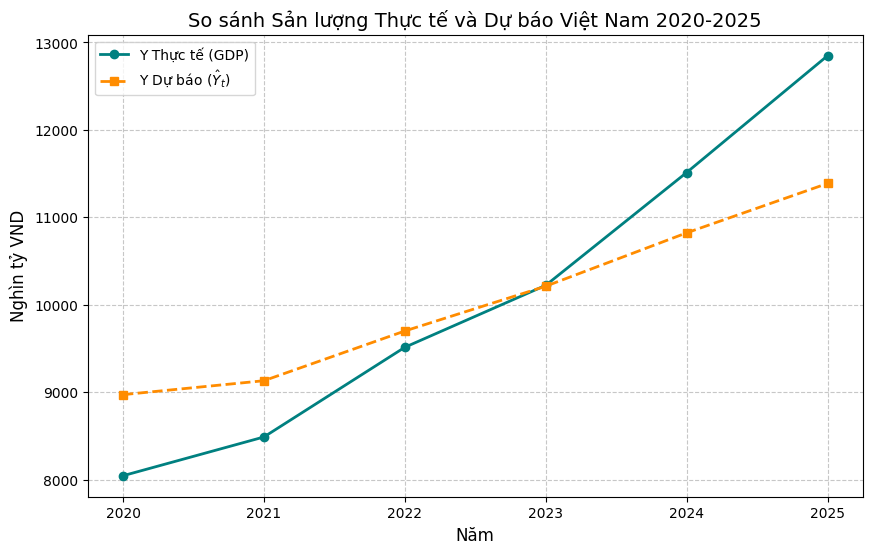

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu vĩ mô và nạp dữ liệu thực tế từ Bảng 1.3 [1, 3-5]
path = '../data/vietnam_macro_2020_2025.csv'
df = pd.read_csv(path)

years = df['year'].values
Y_actual = df['GDP_trillion_VND'].values
K = np.array([16500, 17800, 19600, 21300, 23500, 25900])
L = np.array([53.6, 50.5, 51.7, 52.4, 52.9, 53.4])
D = np.array([12.0, 12.7, 14.3, 16.5, 18.3, 19.5])
AI = np.array([55.6, 60.2, 65.4, 67.0, 73.8, 80.1])
H = np.array([24.1, 26.1, 26.2, 27.0, 28.4, 29.2])

# 2. Khai báo hệ số co giãn [1]
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07

# 3. Tính A_t cho từng năm (kết quả từ Câu 1.4.1) [5]
A_t = Y_actual / (K**alpha * L**beta * D**gamma * AI**delta * H**theta)

# 4. Tính A trung bình giai đoạn 2020-2025 [1]
A_mean = np.mean(A_t)
print(f"Năng suất nhân tố tổng hợp trung bình (A_mean): {A_mean:.4f}\n")

# 5. Tính sản lượng dự báo Y_hat [1, 6]
# Công thức: Y_hat = A_mean * K^alpha * L^beta * D^gamma * AI^delta * H^theta
Y_hat = A_mean * (K**alpha * L**beta * D**gamma * AI**delta * H**theta)

# 6. Tính sai số MAPE (Mean Absolute Percentage Error) [1, 2]
mape = np.mean(np.abs((Y_actual - Y_hat) / Y_actual)) * 100

# 7. Hiển thị bảng so sánh
comparison_df = pd.DataFrame({
    'Năm': years,
    'Y Thực tế': Y_actual,
    'Y Dự báo (Ŷt)': np.round(Y_hat, 2),
    'Chênh lệch (%)': np.round(np.abs((Y_actual - Y_hat) / Y_actual) * 100, 2)
})
print("--- BẢNG SO SÁNH SẢN LƯỢNG THỰC TẾ VÀ DỰ BÁO ---")
print(comparison_df.to_string(index=False))
print(f"\nChỉ số MAPE của mô hình: {mape:.2f}%")

# 8. Vẽ đồ thị so sánh Y thực tế và Y dự báo
plt.figure(figsize=(10, 6))
plt.plot(years, Y_actual, marker='o', label='Y Thực tế (GDP)', color='teal', linewidth=2)
plt.plot(years, Y_hat, marker='s', linestyle='--', label='Y Dự báo ($\hat{Y}_t$)', color='darkorange', linewidth=2)

plt.title('So sánh Sản lượng Thực tế và Dự báo Việt Nam 2020-2025', fontsize=14)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Nghìn tỷ VND', fontsize=12)
plt.xticks(years)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

--- PHÂN RÃ TĂNG TRƯỞNG GDP BÌNH QUÂN HÀNG NĂM 2020-2025 ---
Yếu tố sản xuất  Mức đóng góp (điểm % tăng trưởng)  Tỷ trọng đóng góp (%)
        Vốn (K)                              2.976                  31.78
   Lao động (L)                             -0.031                  -0.34
     Số hóa (D)                              0.971                  10.37
    Năng lực AI                              0.584                   6.24
Nhân lực số (H)                              0.269                   2.87
        TFP (A)                              4.595                  49.08

Tốc độ tăng trưởng GDP bình quân tính toán: 9.36%/năm


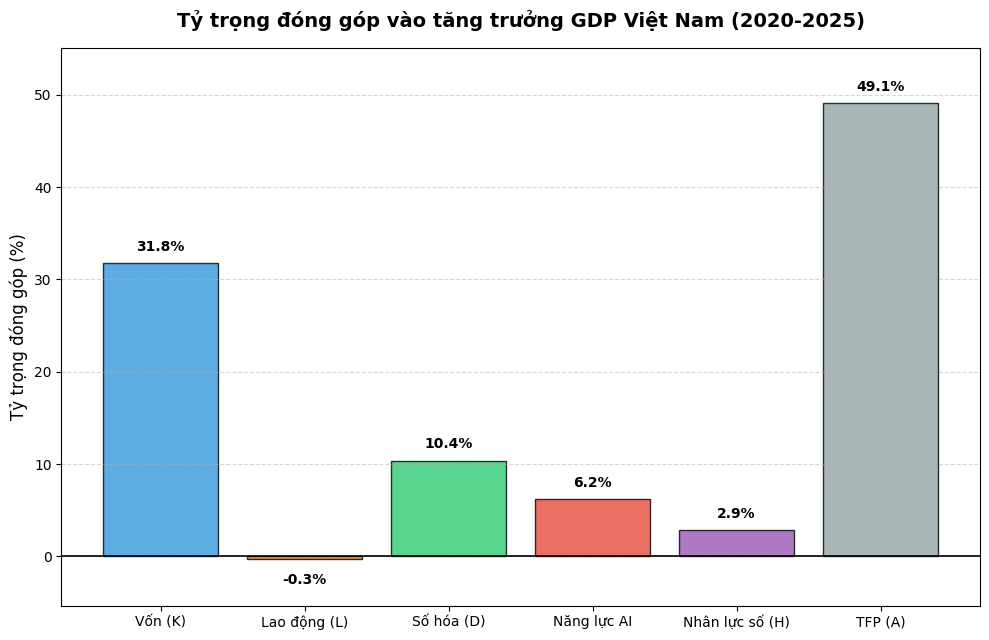

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Đọc dữ liệu từ file CSV và bổ sung dữ liệu thực tế từ Bảng 1.3
path = "../data/vietnam_macro_2020_2025.csv"
# Nếu chạy trên Colab và upload file thẳng, bạn đổi path thành 'vietnam_macro_2020_2025.csv'
try:
    df_csv = pd.read_csv(path, engine="python")
    Y = df_csv["GDP_trillion_VND"].values
except FileNotFoundError:
    # Trường hợp không có file, dùng mảng cứng từ mục 1.3 để code vẫn chạy được
    Y = np.array([8044.4, 8487.5, 9513.3, 10221.8, 11511.9, 12847.6])

# Dữ liệu chính xác theo yêu cầu của Bảng 1.3
years = np.array([2020, 2021, 2022, 2023, 2024, 2025])
K = np.array([16500, 17800, 19600, 21300, 23500, 25900])
L = np.array([53.6, 50.5, 51.7, 52.4, 52.9, 53.4])
D = np.array([12.0, 12.7, 14.3, 16.5, 18.3, 19.5])
AI = np.array([55.6, 60.2, 65.4, 67.0, 73.8, 80.1])
H = np.array([24.1, 26.1, 26.2, 27.0, 28.4, 29.2])

# Hệ số co giãn đề xuất (Elasticities) [3]
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07

# 2. Tính TFP (A_t) cho từng năm bằng cách giải ngược [5, 6]
A = Y / (K**alpha * L**beta * D**gamma * AI**delta * H**theta)

# 3. Tính tốc độ tăng trưởng bình quân hàng năm (g) giai đoạn 2020-2025
# ĐÃ SỬA: Thêm [0] vào cuối để lấy giá trị năm gốc 2020, giúp kết quả trả về là số đơn lẻ (scalar)
n = 5
g_Y = (np.log(Y[-1]) - np.log(Y[0])) / n
g_K = (np.log(K[-1]) - np.log(K[0])) / n
g_L = (np.log(L[-1]) - np.log(L[0])) / n
g_D = (np.log(D[-1]) - np.log(D[0])) / n
g_AI = (np.log(AI[-1]) - np.log(AI[0])) / n
g_H = (np.log(H[-1]) - np.log(H[0])) / n
g_A = (np.log(A[-1]) - np.log(A[0])) / n

# 4. Tính mức đóng góp tuyệt đối của từng nhân tố (Contribution = Elasticity * Growth Rate)
contrib_K = alpha * g_K
contrib_L = beta * g_L
contrib_D = gamma * g_D
contrib_AI = delta * g_AI
contrib_H = theta * g_H
contrib_TFP = g_A

# 5. Tổng hợp dữ liệu vào DataFrame để trình bày bảng [4]
components = [
    "Vốn (K)",
    "Lao động (L)",
    "Số hóa (D)",
    "Năng lực AI",
    "Nhân lực số (H)",
    "TFP (A)",
]
contrib_values = np.array(
    [contrib_K, contrib_L, contrib_D, contrib_AI, contrib_H, contrib_TFP]
)
percent_contrib = (contrib_values / g_Y) * 100

results_df = pd.DataFrame(
    {
        "Yếu tố sản xuất": components,
        "Mức đóng góp (điểm % tăng trưởng)": np.round(contrib_values * 100, 3),
        "Tỷ trọng đóng góp (%)": np.round(percent_contrib, 2),
    }
)

print("--- PHÂN RÃ TĂNG TRƯỞNG GDP BÌNH QUÂN HÀNG NĂM 2020-2025 ---")
print(results_df.to_string(index=False))
print(f"\nTốc độ tăng trưởng GDP bình quân tính toán: {g_Y*100:.2f}%/năm")

# 6. Vẽ biểu đồ cột [4]
plt.figure(figsize=(10, 6.5)) # Tăng nhẹ chiều cao để biểu đồ thoáng hơn
colors = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c", "#9b59b6", "#95a5a6"]
bars = plt.bar(
    components, percent_contrib, color=colors, edgecolor="black", alpha=0.8
)

# Vẽ đường trục hoành y=0 đậm nét hơn để phân tách rõ âm/dương
plt.axhline(0, color="black", linewidth=1.2)

plt.title(
    "Tỷ trọng đóng góp vào tăng trưởng GDP Việt Nam (2020-2025)", 
    fontsize=14, 
    fontweight="bold", 
    pad=15
)
plt.ylabel("Tỷ trọng đóng góp (%)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# ĐIỂM CHỐT LỖI: Mở rộng giới hạn trục y (ylim) thêm 5% ở cả hai đầu
# Giúp chữ không bao giờ bị đụng viền trên hoặc viền dưới của khung hình
plt.ylim(min(percent_contrib) - 5, max(percent_contrib) + 6)

# Thêm nhãn số liệu trên đầu cột (đã xử lý triệt để khoảng cách)
for bar in bars:
    yval = bar.get_height()
    
    # Khoảng cách đệm (offset): Dương thì đẩy lên trên, âm thì kéo hẳn xuống dưới
    offset = 1.0 if yval >= 0 else -1.5 
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + offset,
        f"{yval:.1f}%",
        ha="center",
        va="bottom" if yval >= 0 else "top",
        fontweight="bold",
        color="black"
    )

# Căn chỉnh tự động các lề để không bị cắt chữ khi lưu ảnh
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Khởi tạo dữ liệu gốc tại năm 2025 (từ Bảng 1.3)
# Đây là mốc nền tảng để bắt đầu dự báo
Y_2025 = 12847.6  # GDP (nghìn tỷ VND)
K_2025 = 25900.0  # Vốn (nghìn tỷ VND)
L_2025 = 53.4     # Lao động (triệu người)
D_2025 = 19.5     # Kinh tế số (%)
AI_2025 = 80.1    # AI (nghìn DN)
H_2025 = 29.2     # Nhân lực số (%)

# 2. Khai báo các hệ số co giãn (đề xuất tại mục 1.3)
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07

# 3. Tính năng suất nhân tố tổng hợp A tại năm 2025 (giải ngược)
A_2025 = Y_2025 / (K_2025**alpha * L_2025**beta * D_2025**gamma * AI_2025**delta * H_2025**theta)

# 4. Thiết lập kịch bản đến năm 2030 (n = 5 năm)
n_years = 5

# TFP tăng trưởng 1.2%/năm
A_2030 = A_2025 * (1 + 0.012)**n_years

# K và L tăng trưởng đều 6%/năm
K_2030 = K_2025 * (1 + 0.06)**n_years
L_2030 = L_2025 * (1 + 0.06)**n_years

# D, AI, H đạt mục tiêu kịch bản
D_2030 = 30.0    # Tăng lên 30%
AI_2030 = 100.0  # Đạt 100 nghìn DN
H_2030 = 35.0    # Đạt 35%

# 5. Tính sản lượng dự báo GDP 2030 (Y_2030) theo hàm Cobb-Douglas
Y_2030 = A_2030 * (K_2030**alpha * L_2030**beta * D_2030**gamma * AI_2030**delta * H_2030**theta)

# 6. Trình bày kết quả dự báo
forecast_data = {
    'Chỉ tiêu': ['Năng suất TFP (A)', 'Vốn tích lũy (K)', 'Lao động (L)', 'Kinh tế số (D)', 'Năng lực AI', 'Nhân lực số (H)', 'Dự báo GDP (Y)'],
    'Đơn vị': ['Chỉ số', 'Nghìn tỷ VND', 'Triệu người', '%', 'Nghìn DN', '%', 'Nghìn tỷ VND'],
    'Năm 2025': [np.round(A_2025, 4), K_2025, L_2025, D_2025, AI_2025, H_2025, Y_2025],
    'Năm 2030': [np.round(A_2030, 4), np.round(K_2030, 1), np.round(L_2030, 2), D_2030, AI_2030, H_2030, np.round(Y_2030, 1)]
}

df_forecast = pd.DataFrame(forecast_data)
print("--- KẾT QUẢ MÔ PHỎNG VÀ DỰ BÁO GDP VIỆT NAM NĂM 2030 ---")
print(df_forecast.to_string(index=False))

# Tính tốc độ tăng trưởng GDP bình quân hàng năm giai đoạn 2025-2030
cagr_gdp = ((Y_2030 / Y_2025)**(1/n_years) - 1) * 100
print(f"\nTăng trưởng GDP bình quân hàng năm dự báo (2025-2030): {cagr_gdp:.2f}%")

--- KẾT QUẢ MÔ PHỎNG VÀ DỰ BÁO GDP VIỆT NAM NĂM 2030 ---
         Chỉ tiêu       Đơn vị   Năm 2025   Năm 2030
Năng suất TFP (A)       Chỉ số    34.9136    37.0593
 Vốn tích lũy (K) Nghìn tỷ VND 25900.0000 34660.0000
     Lao động (L)  Triệu người    53.4000    71.4600
   Kinh tế số (D)            %    19.5000    30.0000
      Năng lực AI     Nghìn DN    80.1000   100.0000
  Nhân lực số (H)            %    29.2000    35.0000
   Dự báo GDP (Y) Nghìn tỷ VND 12847.6000 18262.0000

Tăng trưởng GDP bình quân hàng năm dự báo (2025-2030): 7.29%
